In [1]:
using CloudAtlas
using DifferentialEquations
using LinearAlgebra
using Plots
using CairoMakie

[ Info: Precompiling CloudAtlasVisualizationExt [91dd8eae-e5c9-5f98-bbaa-dfe67aeb58cb] (cache misses: include_dependency fsize change (2))


In [2]:
sx, sy, sz, tx, tz = halfbox_symmetries()
α, γ = 2π/6.0, 2π/4.0 
J, K, L = 2, 2, 3
H = [sz*tx]
model = TWModel(α, γ, J, K, L, H, normalize=true)
m = length(model)

J,K,L,m == 2,2,3,88
(2J+1)(2K+1)(2L+1) + 1 == 176
Making matrices B, A1, A2, Cx, Cz...
Phase constraints: keep_cx = true, keep_cz = false
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 


88

In [3]:
R_target = 400.0
f(ξ) = model.g(ξ, R_target)
Df(ξ) = model.Dg(ξ, R_target)
xnorm = 0.40
ξ_guess = zeros(m + 2)
ξ_star = ξ_guess;

In [26]:
while true
    x_guess = randn(m)
    x_guess = xnorm/norm(x_guess) * x_guess
    cx_guess = randn() * 0.1
    cz_guess = 0
    ξ_guess = [x_guess; cx_guess; cz_guess]
    params = SearchParams(ftol=1e-6, xtol=1e-6, Nnewton=30, Nhook=8, verbosity=0)
    ξ_star, converged = hookstepsolve(f, Df, ξ_guess, params)
    print(".")
    if converged && norm(ξ_star[1:m]) > 1e-3 && ξ_star[end - 1] > 1e-1
        println("\nConverged:", converged)
        break
    end
end

.....................................
Converged:true


In [27]:
norm(ξ_star[1:m]), ξ_star[end - 1 ], ξ_star[end]

(0.21876479271014598, 0.22504548278566391, 0.0)

In [28]:
(2π/α)/ξ_star[end - 1]

26.661277203748515

Building dissipation matrix...


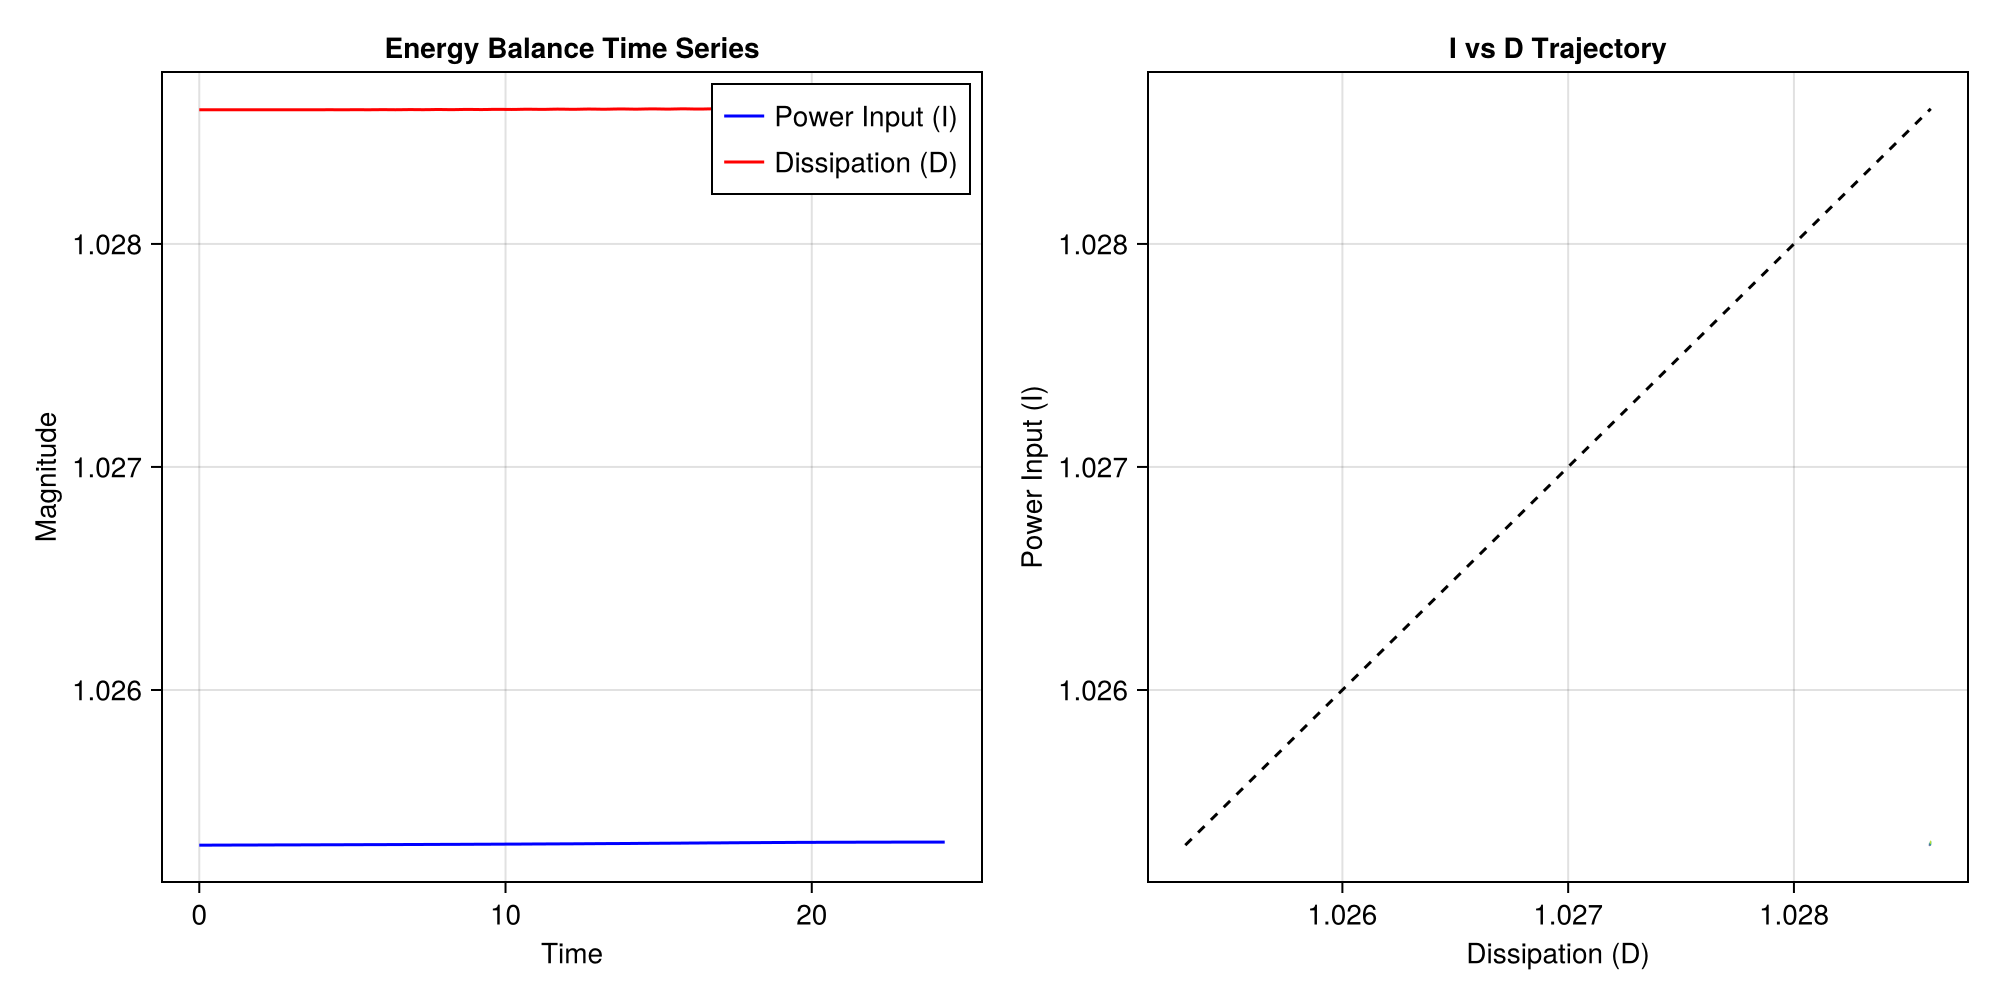

In [45]:
sol = integrate_flow(model, ξ_star, (0.0, (2π/α)/ξ_star[end - 1]), saveat = 0.1, lab_frame = false);
D_matrix = build_dissipation_matrix(model)
plot_id_series(model, sol, D_matrix)

In [43]:
sol = integrate_flow(model, ξ_guess, (0.0, 1000), saveat = 0.1, lab_frame = false);
# sol = integrate_flow(model, ξ_star, (0.0, 1.0), saveat = 0.1, lab_frame = false);

Building dissipation matrix...


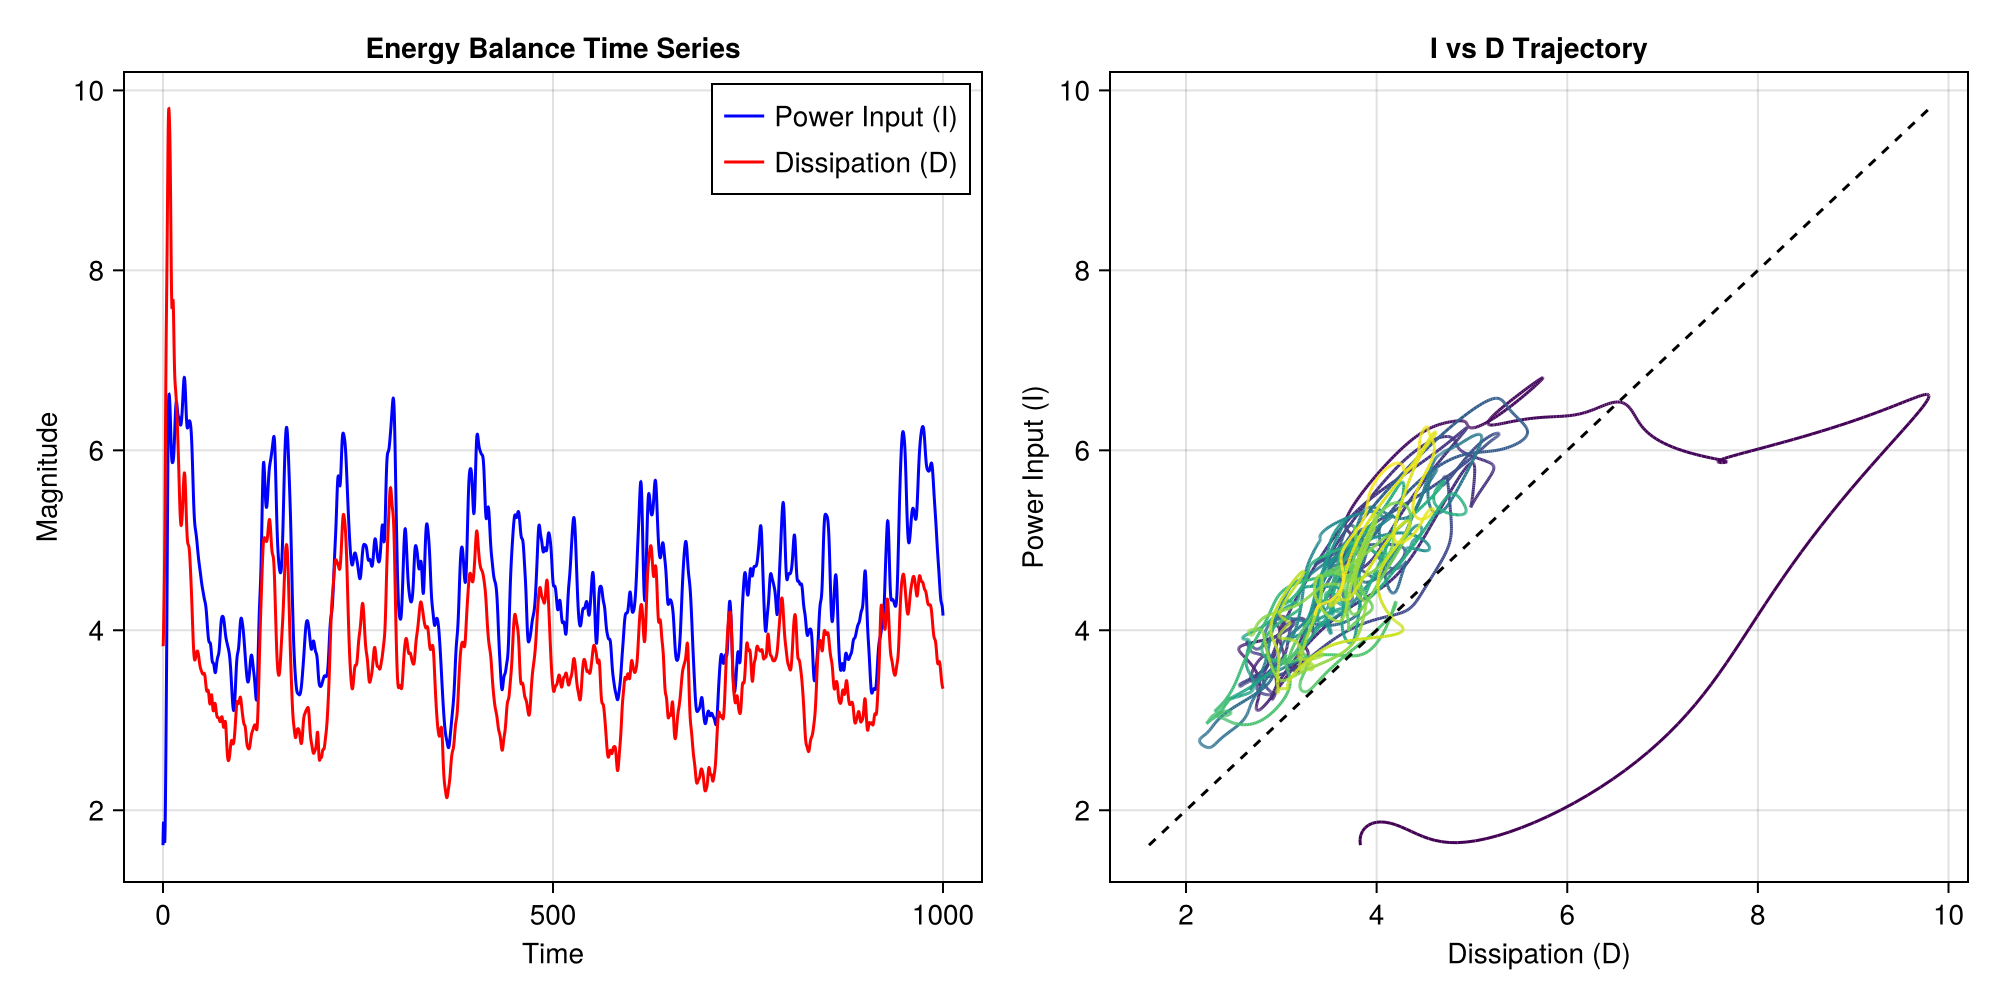

In [44]:
D_matrix = build_dissipation_matrix(model)
plot_id_series(model, sol, D_matrix)

In [19]:
# animate_flow(model, sol, "traveling_wave_fastx.mp4"; add_baseflow=true )
# animate_tw_fluctuations(model, ξ_star, "fluctations_of_tw.mp4")

In [20]:
# animate_flow(model, sol, "tw_bf_2025_12_09.mp4"; add_baseflow=true )

In [21]:
# animate_flow(model, sol, "tw_2025_12_09.mp4"; settings=PlotSettings(arrow_scale = 2.0, arrow_lengthscale = 0.8, arrow_tiplength= 14.0, arrow_tipwidth = 14.0, arrow_shaftwidth= 2.0) , add_baseflow=false)

Computing eigenvalues for m=88 system...


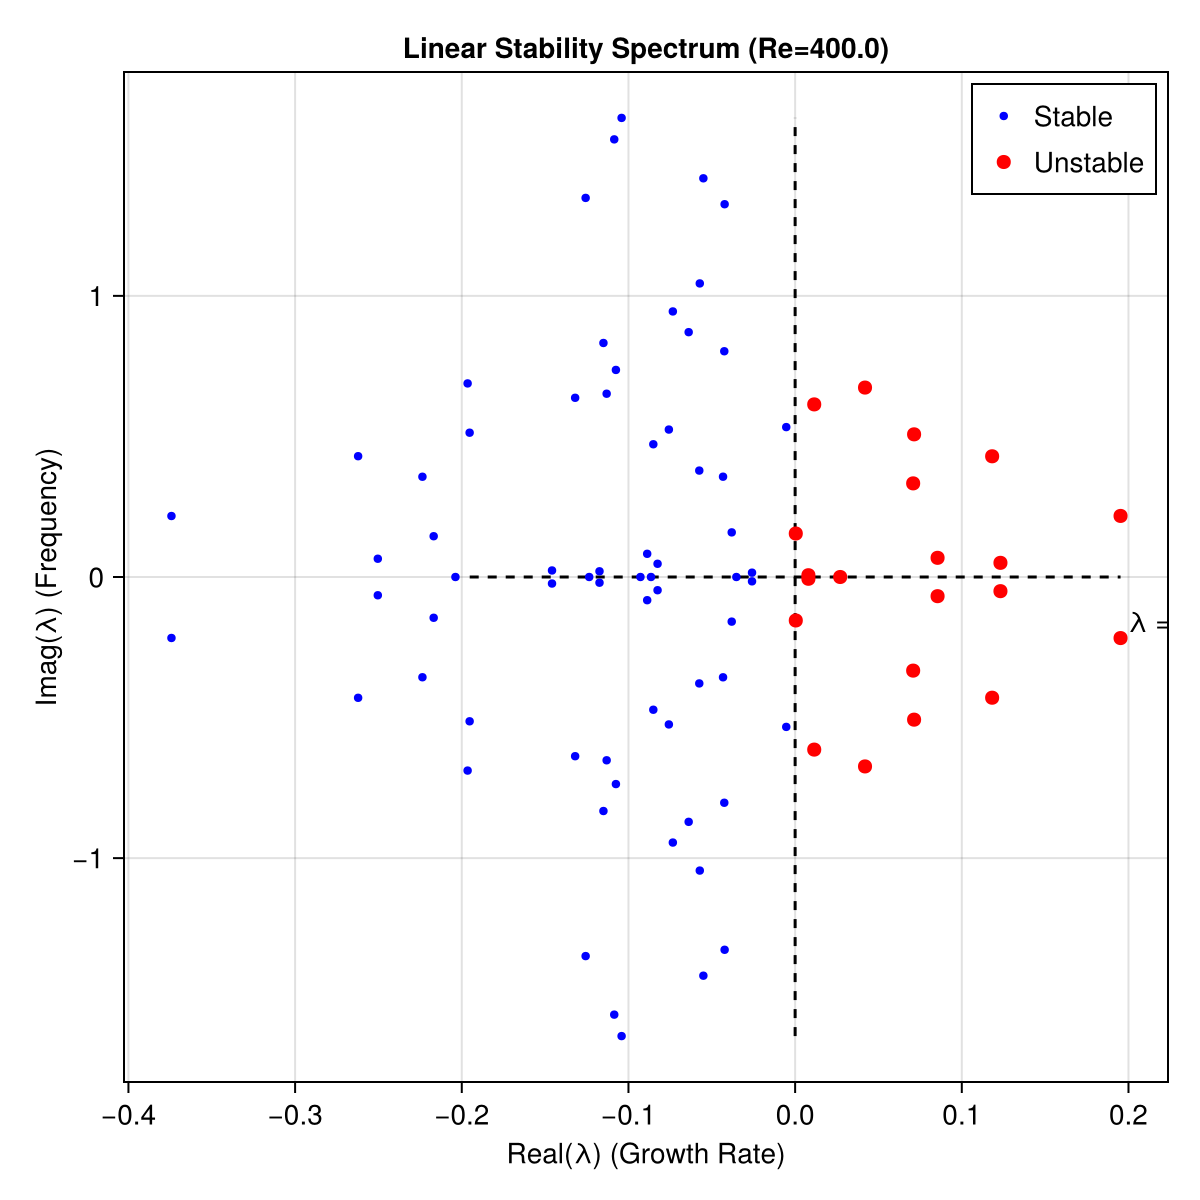

In [30]:
plot_stability_spectrum(model, ξ_star, R_target)

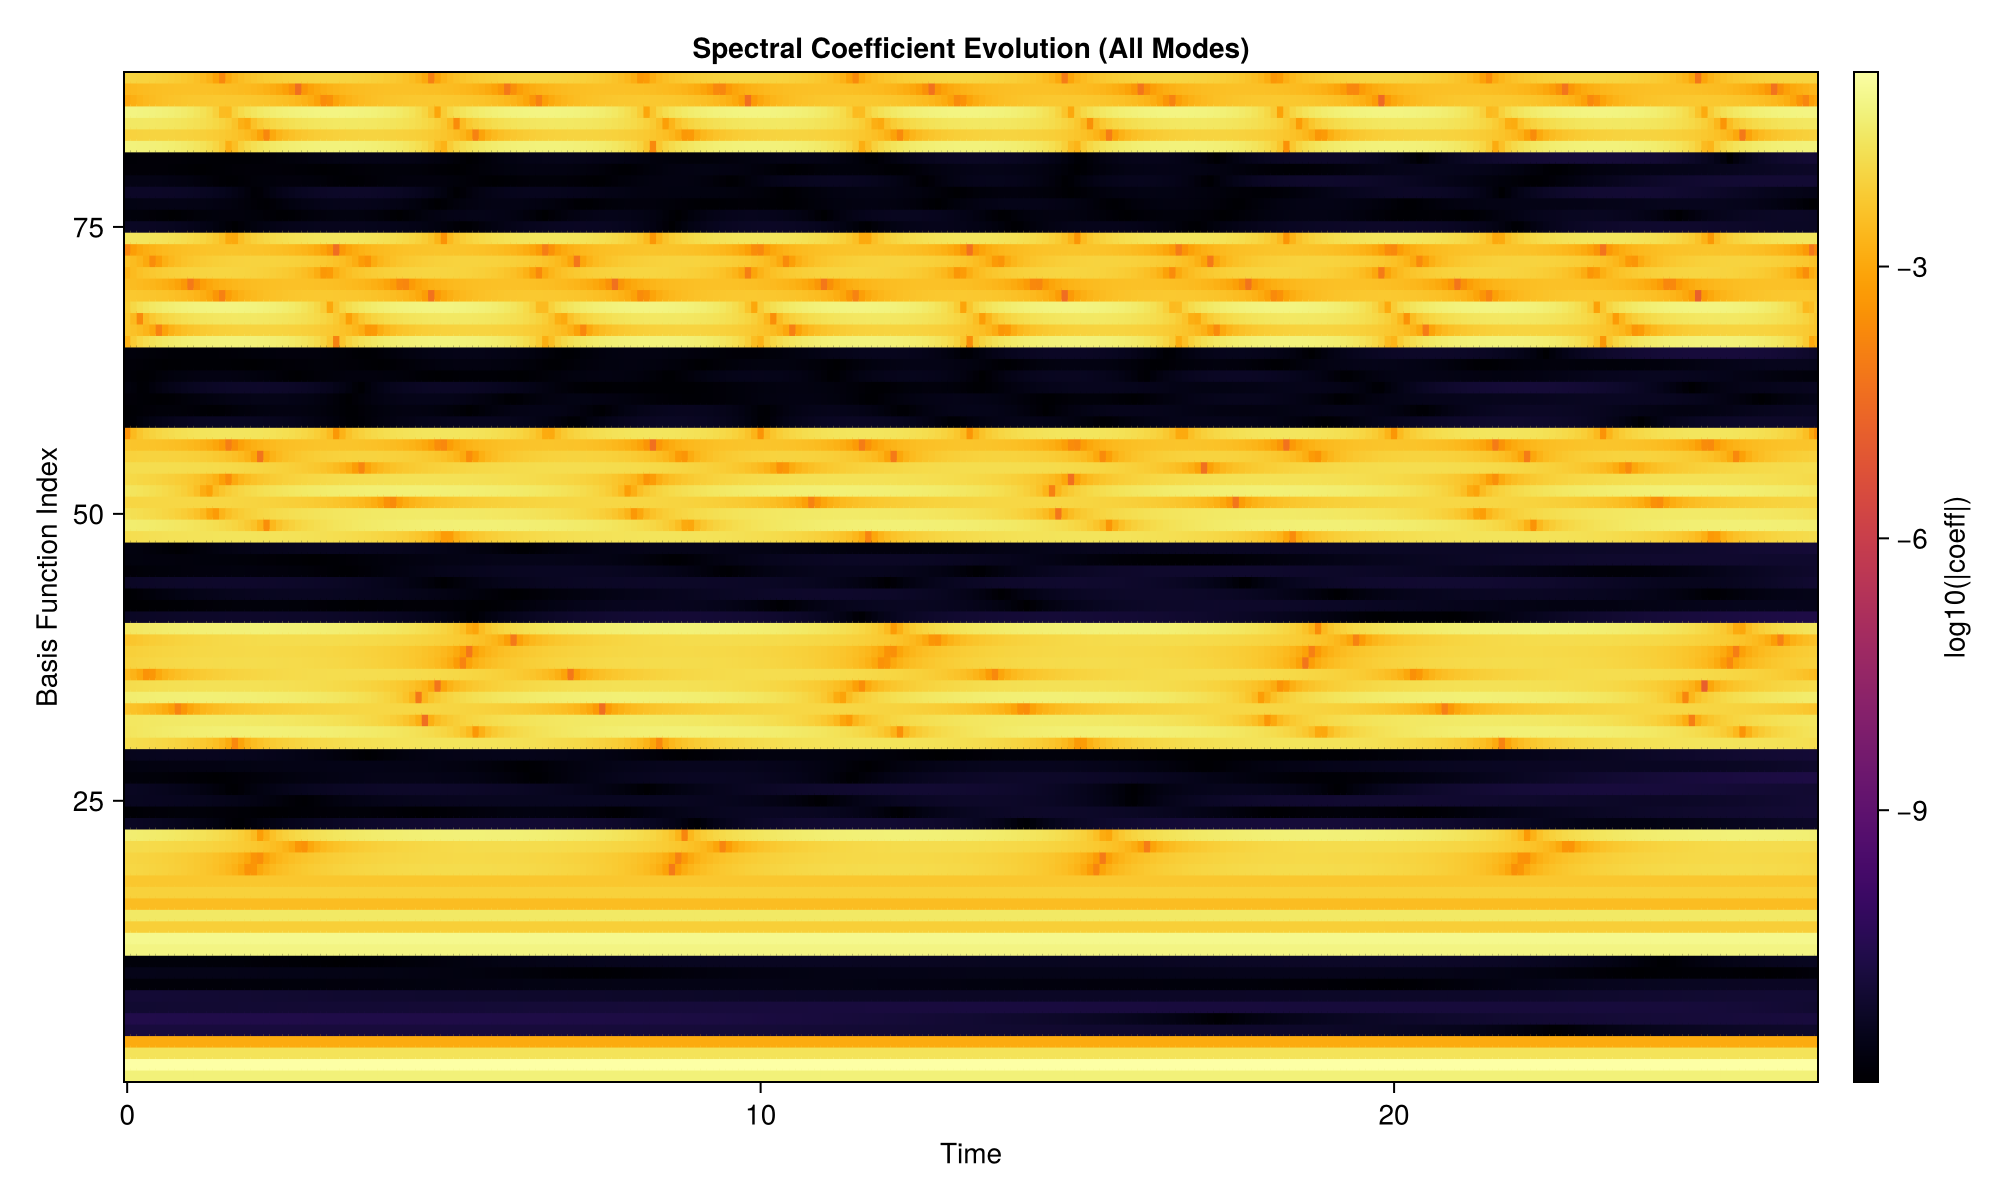

In [31]:
plot_coefficient_evolution(model, sol)

..........
Converged:true
Norms: 0.04224433443012166
Wavespeed cx: 0.24649463286509748
Wavespeed cz: 0.0
Computing eigenvalues for m=88 system...


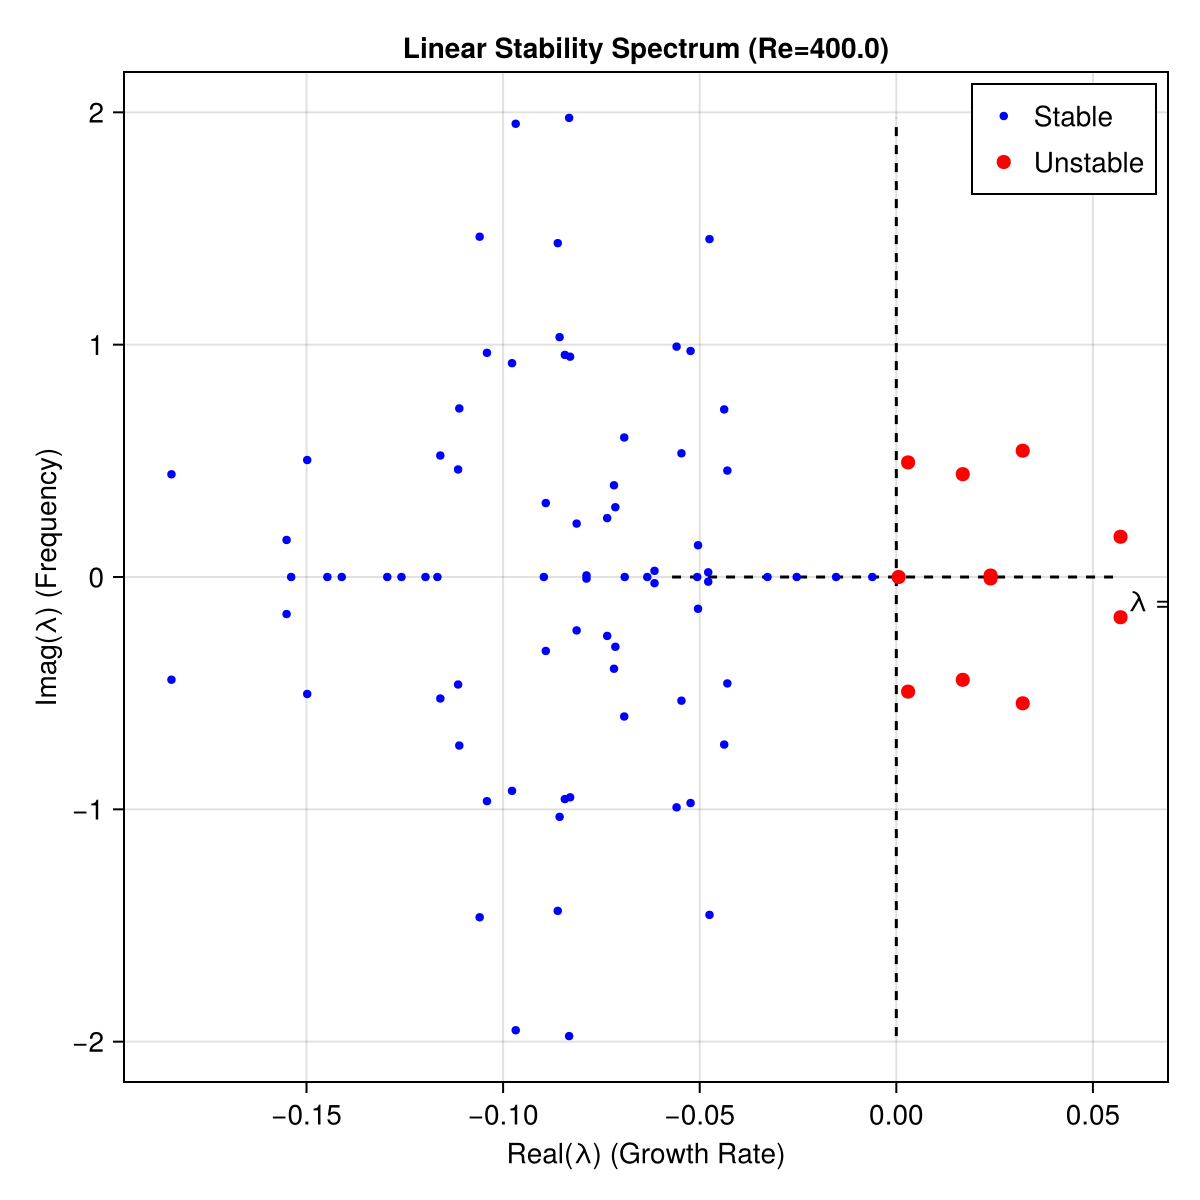

In [33]:
while true
    x_guess = randn(m)
    x_guess = xnorm/norm(x_guess) * x_guess
    cx_guess = randn() * 0.1
    cz_guess = 0
    ξ_guess = [x_guess; cx_guess; cz_guess]
    params = SearchParams(ftol=1e-6, xtol=1e-6, Nnewton=30, Nhook=8, verbosity=0)
    ξ_star, converged = hookstepsolve(f, Df, ξ_guess, params)
    print(".")
    if converged && norm(ξ_star[1:m]) > 1e-3 && ξ_star[end - 1] > 1e-1
        println("\nConverged:", converged)
        break
    end
end
println("Norms: ", norm(ξ_star[1:m]), "\nWavespeed cx: ", ξ_star[end - 1 ], "\nWavespeed cz: ", ξ_star[end])
sol = integrate_flow(model, ξ_star, (0.0, (2π/α)/ξ_star[end - 1]), saveat = 0.1, lab_frame = false);
plot_stability_spectrum(model, ξ_star, R_target)

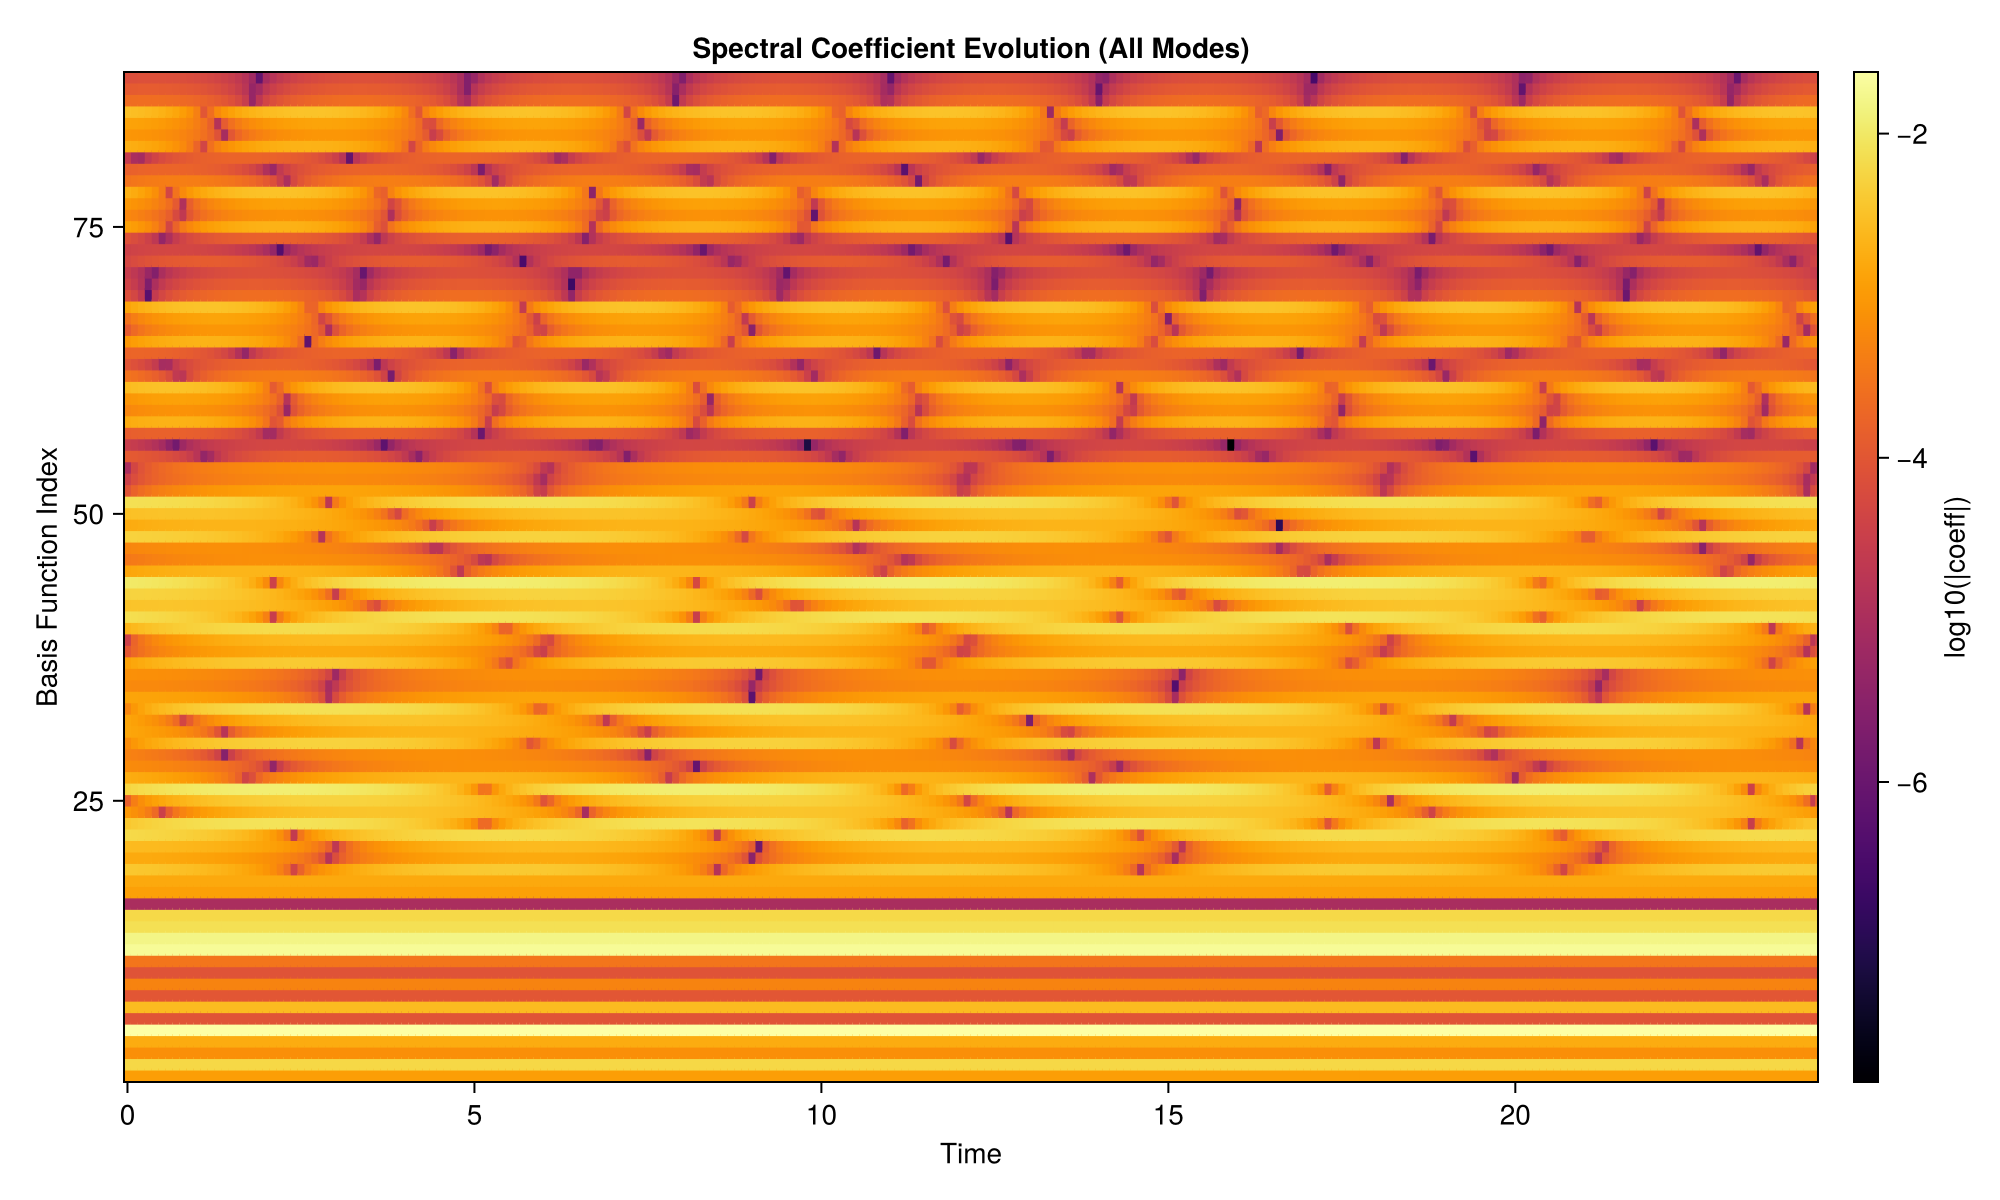

In [34]:
plot_coefficient_evolution(model, sol)

In [39]:
using Dates
using ChannelflowWrapper
Re = R_target

reference_field_converted = "reference_field_$(α)_$(γ).nc"
reference_path = "./TW1-2pi1piRe200-40x49x40.nc"
changegrid(reference_path, reference_field_converted; al=α, ga=γ);

base_dir="cont_results"
m = model.m
T = 10.0
symm_file = "./sztx.asc"

timestamp = Dates.format(now(), "MM-DD-HHMMSS")
sol_dir = joinpath(base_dir, "sol_$(J)_$(K)_$(L)_$(timestamp)")
mkpath(sol_dir)
guess_path = joinpath(sol_dir, "u_guess.nc")
sigma_file = joinpath(sol_dir, "sigma.asc")

coeff2field(ξ_star[1:m], model.ijkl, reference_field_converted, guess_path)
save_sigma(model, ξ_star[end - 1], ξ_star[end], T, sigma_file)

try
    findsoln(guess_path;
        R = Re, eqb = true, xrel = model.keep_cx, zrel = model.keep_cz,
        symms = abspath(symm_file), sigma = sigma_file, od = sol_dir, T = T
    )
catch e
    println("findsoln failed: $e")
end


Leaving rescale
L2Norm(u0)  == 0.2792590266581449
L2Norm(u1)  == 0.2792590266581447
bcNorm(u0)  == 8.737886593015271e-17
bcNorm(u1)  == 7.538105990587311e-17
divNorm(u0) == 4.746636220033689e-16
divNorm(u1) == 4.887049111322837e-16
L2Norm(u2)  == 0.2792590266581447
divNorm(u2) == 6.695391529748956e-18
bcNorm(u2)  == 7.600850059449384e-17
alpha, gamma == 1.047197551196598, 1.570796326794897
Nx, Ny, Nz == 40, 49, 40
Reading ijkl indices of basis set from file
reading N == 88 ijkl indices
ijkl[0] == 1 0 0 0
L == max l == 3
Constructing Legendre polynomials
Assigning Polynomial, size = 1 
Assigning Polynomial, size = 0 1 
Assigning Polynomial, size = -0.5 0 1.5 
Assigning Polynomial, size = 0 -1.5 0 2.5 
Constructing S, and Sprime polynomials
Assigning Polynomial, size = 0 1 0 -0.3333333333333333 
Assigning Polynomial, size = 1 0 -2 0 1 
Assigning Polynomial, size = 0 1 0 -2 0 1 
Assigning Polynomial, size = -0.5 0 2.5 0 -3.5 0 1.5 
Assigning Polynomial, size = 1 0 -1 
Assigning Polynomial

f^T: ....10
Newton iteration number 0
Current state of Newton iteration:
   fcount_newton   == 1
   fcount_optimiza == 0
   L2Norm(x)       == 0.0199852
   L2Norm(dxN)     == 0
   L2Norm(dxOpt)   == 0
   L2Dist(x,x0)    == 0
gx == L2Norm(G(x)) : 
   initial  gx == 0.00129638
   previous gx == 0.00129638
   current  gx == 0.00129638
rx == 1/2 L2Norm2(G(x)) : 
   initial  rx == 8.403e-07
   previous rx == 8.403e-07
   current  rx == 8.403e-07
         delta == 0.01
Newt,GMRES == 0,0, f^T: ....10 res == 0.755947
Newt,GMRES == 0,1, f^T: ....10 res == 0.387282
Newt,GMRES == 0,2, f^T: ....10 res == 0.360531
Newt,GMRES == 0,3, f^T: ....10 res == 0.351597
Newt,GMRES == 0,4, f^T: ....10 res == 0.3474
Newt,GMRES == 0,5, f^T: ....10 res == 0.346887
Newt,GMRES == 0,6, f^T: ....10 res == 0.342811
Newt,GMRES == 0,7, f^T: ....10 res == 0.336178
Newt,GMRES == 0,8, f^T: ....10 res == 0.335769
Newt,GMRES == 0,9, f^T: ....10 res == 0.320896
Newt,GMRES == 0,10, f^T: ....10 res == 0.293272
Newt,GMRES == 0,

Process(setenv(`/home/ebenq/.julia/artifacts/6c1f2435997ed534492ee48fcb3cbe0e484642f9/bin/findsoln -R 400.0 -eqb -xrel -symms /home/ebenq/Dev/julia/CloudAtlas.jl/notebooks/time-integration/sztx.asc -sigma cont_results/sol_2_2_3_43-DD-004356/sigma.asc -od cont_results/sol_2_2_3_43-DD-004356 -T 10.0 cont_results/sol_2_2_3_43-DD-004356/u_guess.nc`,["PATH=/home/ebenq/.julia/artifacts/7f39a18d94f87b5135df6731a327b61b8c463af6/bin:/home/ebenq/.julia/artifacts/235aa219585823fcc7f270b3d0efdaec60267f1b/bin:/home/ebenq/.julia/artifacts/4a89e14d2f652ad45bcc093d040c97fbcc1a3669/bin:/home/ebenq/.julia/artifacts/fddb41451df711c595969c8571404433623c75f6/bin:/home/ebenq/.julia/artifacts/117d9048128625bb3418b0b4cca48739c5d28740/bin:/home/ebenq/.julia/artifacts/2117b531439d782e1cb0ebffcc4dcf11d274cc39/bin:/home/ebenq/.julia/artifacts/8c83eff7b29912d7bd1e42aef04f7822159494c3/bin:/home/ebenq/.julia/artifacts/4db1e58d71ac6bbb35ecc832033264c630d5d3b3/bin:/home/ebenq/.julia/artifacts/45a076ac2b0b5e528159c9614